In [146]:
#%pip install scipy

In [147]:
#Imports

import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [148]:
#Data Parsing

#Open and read the dataset file
with open("dataset_", "r") as f:
    lines = f.readlines()

#Skip to where the data actually starts in the file
data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

#From here parse the dataset into a usable dataset
dataset = pd.read_csv("dataset_", skiprows=data_start+1, header=None)

#Get the feature column
dataset.columns = ['id','rated','created_at','last_move_at','turns','victory_status','winner','increment_code','white_id','white_rating','black_id','black_rating','moves','opening_eco','opening_name','opening_ply']

#Look at the dataset before preprocessing
dataset.head()



,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,a-00,1191,'d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba...,D10,'Slav Defense: Exchange Variation',5
1,l1NXvwaE,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,skinnerua,1261,'d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc...,B00,'Nimzowitsch Defense: Kennedy Variation',4
2,mIICvQHh,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,a-00,1500,'e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 N...,C20,'King\'s Pawn Game: Leonardis Variation',3
3,kWKvrqYL,True,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,'d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 ...,D02,'Queen\'s Pawn Game: Zukertort Variation',3
4,9tXo1AUZ,True,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,adivanov2009,1469,'e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 ...,C41,'Philidor Defense',5


In [149]:
#Data Preprocessing

# Additional Feature Extraction, Some additional features can be extracted to provide relevent data

#rating_diff: the difference in rating between players
#base_time: the base time amount set for the game
#time_increment: the time gained per move
#opening_strategy: Strategy of opening correlating to eco code letter (A, B, C, D, E)

dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"] 
dataset[["base_time", "time_increment"]] = dataset["increment_code"].str.split("+", expand=True) 
dataset["opening_strategy"] = dataset["opening_eco"].str[0] 


#Feature Refinement (Convert features to values that can be used in analysis)

#Convert time to integers
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

#Get unique values of opening code and victory type
opening_strategy_values = dataset["opening_strategy"].unique()

winner_values = dataset["winner"].unique()
victory_status_values = dataset["victory_status"].unique()


#Data encoding (Encode non-numeric feature data into representative values that can be used for anlaysis)

#Create encoder to convert string data to binary array data
encoder = OneHotEncoder(categories=[opening_strategy_values, winner_values, victory_status_values], handle_unknown="ignore", sparse_output=False)

#Encode the data to unique values
encoded_Data = encoder.fit_transform(dataset[["opening_strategy", "winner", "victory_status"]])

#Create a dataframe from the encoded data to be appended to the dataset
encoded_dataframe = pd.DataFrame(encoded_Data, columns=encoder.get_feature_names_out(["opening_strategy", "winner", "victory_status"]), index = dataset.index)

#Append the encoded data to the dataset
dataset = pd.concat([dataset, encoded_dataframe], axis=1)



dataset.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_strategy_C,opening_strategy_A,opening_strategy_E,winner_white,winner_black,winner_draw,victory_status_outoftime,victory_status_resign,victory_status_mate,victory_status_draw
0,TZJHLljE,False,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,l1NXvwaE,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,mIICvQHh,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,kWKvrqYL,True,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9tXo1AUZ,True,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


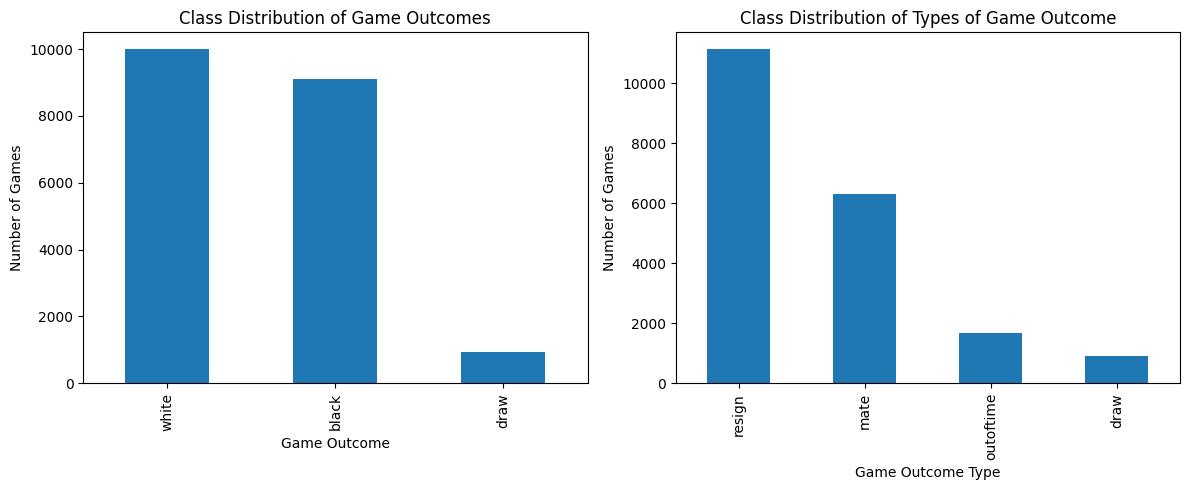

In [150]:
# get the number of each game outcome
winner_class_counts = dataset["winner"].value_counts()

# get the number of each victory type
type_winner_class_counts = dataset["victory_status"].value_counts()

# create two plots in one figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# plot winner distribution
winner_class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Game Outcome")
axes[0].set_ylabel("Number of Games")

# plot victory type distribution
type_winner_class_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Types of Game Outcome")
axes[1].set_xlabel("Game Outcome Type")
axes[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.show()

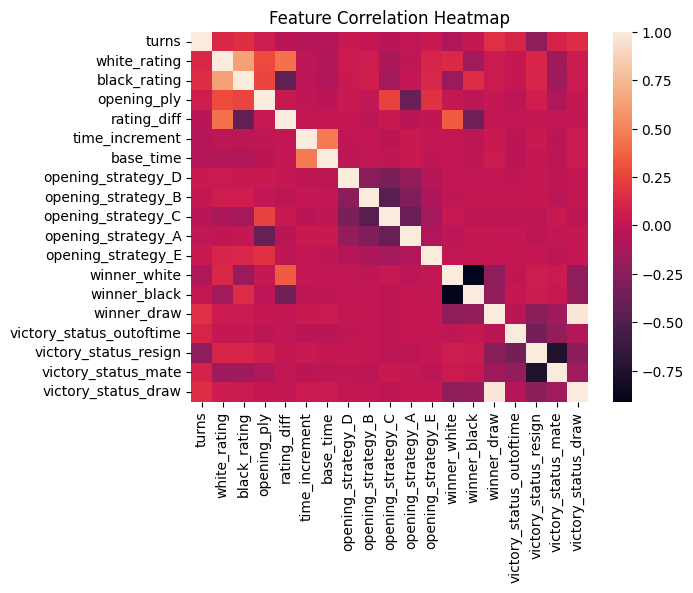

In [151]:
#use only the numeric features
numeric_features = dataset[["turns", "white_rating", "black_rating", "opening_ply", "rating_diff", "time_increment", "base_time"] + list(encoded_dataframe.columns)]

#Create a correlation matrix
corr_matrix = numeric_features.corr()

# Plot feature heatmap
plt.figure()
seaborn.heatmap(corr_matrix)

plt.title("Feature Correlation Heatmap")
plt.show()